# June30_4 step-by-step output document

This notebook documents the saved `june30_4` analysis that is stored in this repository as `june30_4_best`.

It explains, step by step, how the final strict annotated video and the three-point speckle overlay are produced. The notebook reads the current saved outputs by default, generates documentation screenshots, and shows the exact variables and functions used. It does not re-run or overwrite the videos unless you explicitly switch the regeneration flags at the end.


## Pipeline map

| Step | What happens | Main functions | Main variables and outputs |
|---|---|---|---|
| 1 | Locate input data and saved run artifacts | `Path`, `json.loads`, `np.load`, `cv2.VideoCapture` | `VIDEO_PATH`, `ROI_PATH`, `STRICT_NPZ_PATH`, `metadata`, `arrays` |
| 2 | Load ROIs and measurement scale | `roi.load_rois`, `resolve_measurement_pixel_scale` | `rois`, `mm_per_pixel`, `measurement_scale_source` |
| 3 | Run strict UltraTimTrack-style detection and filtering | `detect_timtrack_geofeature_from_image`, `run_matlab_aponeurosis_state_video`, `run_matlab_2state_kalman`, `compute_speckle_coherence` | `sup_apo_lines`, `deep_apo_lines`, `fascicle_segments`, `FL_px`, `FL_mm`, `PEN_deg`, `ANG_deg`, `combined_confidence` |
| 4 | Write the strict annotated MP4 | `save_annotated_video`, `draw_overlay_frame` | `ANNOTATED_VIDEO_PATH`, `arrays`, `fps`, `show_kalman_comparison` |
| 5 | Select three speckle points on the fascicle | `_speckle_config_from_box`, `_candidate_score_rows`, `_select_three_speckle_points` | `box_size_px`, `requested_offset_px`, `selected_offset_px`, `initial_points`, `candidate_scores` |
| 6 | Track the three points frame to frame | `_match_speckle_point_with_fb`, `_track_speckle_points_independent`, `_strain_arrays` | `positions`, `dxdy`, `zncc`, `forward_backward_error`, `valid`, `fallback_used`, `strain_back_front_percent` |
| 7 | Write the speckle Excel file and overlay MP4 | `_speckle_tracking_rows`, `_speckle_summary_rows`, `_write_simple_xlsx`, `_write_speckle_overlay_video`, `generate_three_point_speckle_outputs` | `SPECKLE_XLSX_PATH`, `SPECKLE_OVERLAY_PATH` |


In [1]:
from __future__ import annotations

import json
import math
import os
import sys
import zipfile
from pathlib import Path
from xml.etree import ElementTree as ET

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, Video, display

ROOT = Path.cwd().resolve()
if not (ROOT / "ultrasound_tracker").exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import ultrasound_tracker.roi as roi

DATASET_NAME = "june30_4_best"
RUN_DIR = ROOT / "results" / "strict_ultratimtrack_runs" / DATASET_NAME
VIDEO_PATH = ROOT / "data" / "raw" / f"{DATASET_NAME}.AVI"
ROI_PATH = ROOT / "data" / "rois" / f"{DATASET_NAME}_rois.json"
STRICT_NPZ_PATH = RUN_DIR / f"{DATASET_NAME}_strict_results.npz"
STRICT_METADATA_PATH = RUN_DIR / f"{DATASET_NAME}_strict_metadata.json"
ANNOTATED_VIDEO_PATH = RUN_DIR / f"{DATASET_NAME}_strict_annotated.mp4"

SPECKLE_BOX_SIZE_PX = 41
SPECKLE_REQUESTED_OFFSET_PX = 45.0
SPECKLE_SELECTED_OFFSET_LABEL = 45
SPECKLE_XLSX_PATH = RUN_DIR / f"{DATASET_NAME}_three_point_speckle_tracking_box{SPECKLE_BOX_SIZE_PX}px_offset{SPECKLE_SELECTED_OFFSET_LABEL}px.xlsx"
SPECKLE_OVERLAY_PATH = RUN_DIR / f"{DATASET_NAME}_three_point_speckle_overlay_box{SPECKLE_BOX_SIZE_PX}px_offset{SPECKLE_SELECTED_OFFSET_LABEL}px.mp4"

DOC_DIR = ROOT / "results" / DATASET_NAME / "step_by_step_documentation"
DOC_DIR.mkdir(parents=True, exist_ok=True)

required_paths = {
    "raw video": VIDEO_PATH,
    "ROI JSON": ROI_PATH,
    "strict NPZ": STRICT_NPZ_PATH,
    "strict metadata": STRICT_METADATA_PATH,
    "strict annotated MP4": ANNOTATED_VIDEO_PATH,
    "three-point speckle XLSX": SPECKLE_XLSX_PATH,
    "three-point speckle MP4": SPECKLE_OVERLAY_PATH,
}
missing = [name for name, path in required_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing required artifacts: {missing}")

path_rows = []
for name, path in required_paths.items():
    path_rows.append({"artifact": name, "path": str(path), "size_MB": path.stat().st_size / 1024**2})
path_df = pd.DataFrame(path_rows)
display(path_df)
print(f"Documentation images will be written to: {DOC_DIR}")


,artifact,path,size_MB
0,raw video,/Users/grosbedou/PycharmProjects/NDORMS/data/r...,15.642628
1,ROI JSON,/Users/grosbedou/PycharmProjects/NDORMS/data/r...,0.000216
2,strict NPZ,/Users/grosbedou/PycharmProjects/NDORMS/result...,0.601540
3,strict metadata,/Users/grosbedou/PycharmProjects/NDORMS/result...,0.002452
4,strict annotated MP4,/Users/grosbedou/PycharmProjects/NDORMS/result...,4.400592
5,three-point speckle XLSX,/Users/grosbedou/PycharmProjects/NDORMS/result...,0.048154
6,three-point speckle MP4,/Users/grosbedou/PycharmProjects/NDORMS/result...,4.340283


Documentation images will be written to: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/step_by_step_documentation


## 1. Load the saved run

The strict run has already produced a `.npz` file containing per-frame arrays and a metadata JSON file containing the settings. In the strict runner, these values are created inside `process_video()` and then saved near the end of the run.

Important variables loaded here:

| Variable | Meaning |
|---|---|
| `metadata` | Settings and provenance for the run: raw video, ROI path, frame count, fps, Kalman mode, scale. |
| `arrays` | Numeric per-frame results from the strict pipeline. This includes lines, FL/PEN/ANG, confidence, and Kalman state arrays. |
| `rois` | The superficial aponeurosis, deep aponeurosis, and fascicle boxes used to constrain detection. |
| `frames`, `fps`, `mm_per_pixel` | Basic sequence information used for timing and physical units. |


In [2]:
metadata = json.loads(STRICT_METADATA_PATH.read_text())
with np.load(STRICT_NPZ_PATH, allow_pickle=True) as npz:
    arrays = {key: npz[key] for key in npz.files}
rois = roi.load_rois(ROI_PATH)

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise FileNotFoundError(VIDEO_PATH)
fps_cv2 = float(cap.get(cv2.CAP_PROP_FPS))
video_frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
ok, first_bgr = cap.read()
cap.release()
if not ok:
    raise RuntimeError(f"Could not read first frame from {VIDEO_PATH}")
first_gray = cv2.cvtColor(first_bgr, cv2.COLOR_BGR2GRAY) if first_bgr.ndim == 3 else first_bgr.copy()
frame_shape = first_gray.shape[:2]

fps = float(metadata.get("fps") or fps_cv2)
frame_numbers = np.asarray(arrays["frame"], dtype=int)
time_s = np.asarray(arrays["time_s"], dtype=np.float64)
mm_per_pixel = float(np.asarray(arrays.get("mm_per_pixel", np.nan)).reshape(-1)[0])

run_summary = pd.DataFrame(
    [
        {"name": "dataset", "value": DATASET_NAME},
        {"name": "frames in strict result", "value": len(frame_numbers)},
        {"name": "frames in raw video", "value": video_frame_count},
        {"name": "fps", "value": fps},
        {"name": "frame shape", "value": f"{frame_shape[1]} x {frame_shape[0]} px"},
        {"name": "mm_per_pixel", "value": mm_per_pixel},
        {"name": "measurement_scale_source", "value": metadata.get("measurement_scale_source")},
        {"name": "kalman_mode", "value": metadata.get("kalman_mode")},
        {"name": "adaptive_r", "value": metadata.get("adaptive_r")},
        {"name": "compare_to_fixed_kalman", "value": metadata.get("compare_to_fixed_kalman")},
    ]
)
display(run_summary)

key_arrays = [
    "frame",
    "time_s",
    "sup_apo_lines",
    "deep_apo_lines",
    "fascicle_segments",
    "fascicle_end_segments",
    "klt_prior_segments",
    "FL_px",
    "FL_mm",
    "PEN_deg",
    "ANG_deg",
    "combined_confidence",
    "r_scale_theta",
    "r_scale_length",
    "speckle_zncc",
    "speckle_confidence",
]
array_rows = []
for key in key_arrays:
    if key not in arrays:
        continue
    value = np.asarray(arrays[key])
    sample = value.reshape(-1)[:4]
    array_rows.append(
        {
            "array": key,
            "shape": str(value.shape),
            "dtype": str(value.dtype),
            "first values": np.array2string(sample, precision=3, separator=", "),
        }
    )
display(pd.DataFrame(array_rows))


,name,value
0,dataset,june30_4_best
1,frames in strict result,84
2,frames in raw video,84
3,fps,11.0
4,frame shape,800 x 800 px
5,mm_per_pixel,0.08625
6,measurement_scale_source,entered_image_depth_mm
7,kalman_mode,adaptive-anisotropic
8,adaptive_r,True
9,compare_to_fixed_kalman,True


,array,shape,dtype,first values
0,frame,"(84,)",int32,"[0, 1, 2, 3]"
1,time_s,"(84,)",float64,"[0. , 0.091, 0.182, 0.273]"
2,sup_apo_lines,"(84, 4)",float64,"[ 1. , 97.31, 800. , 90.49]"
3,deep_apo_lines,"(84, 4)",float64,"[ 1. , 345.5, 800. , 345.5]"
4,fascicle_segments,"(84, 4)",float64,"[ 921.213, 89.456, -121.213, 345.5 ]"
5,fascicle_end_segments,"(84, 4)",float64,"[ 921.213, 89.456, -121.213, 345.5 ]"
6,klt_prior_segments,"(84, 4)",float64,"[ 921.213, 89.456, -121.213, 345.5 ]"
7,FL_px,"(84,)",float64,"[1073.411, 1077.058, 1081.93 , 1111.013]"
8,FL_mm,"(84,)",float64,"[92.582, 92.896, 93.316, 95.825]"
9,PEN_deg,"(84,)",float64,"[13.8 , 13.759, 13.74 , 13.602]"


## 2. Check the ROI and first frame

The strict runner starts from the raw image and the ROI JSON. The ROI boxes restrict where the aponeuroses and fascicles are detected.

Brief function notes:

| Function | Role |
|---|---|
| `roi.load_rois(ROI_PATH)` | Reads the saved ROI rectangles from JSON. |
| `update_parms_from_rois(parms, rois, frame_shape)` | Copies ROI settings into the MATLAB-style parameter structure used by the detector. |
| `ellipse_mask_from_roi(shape, fascicle_roi)` | Converts the fascicle ROI into the elliptical fascicle mask used by the Hough detector. |


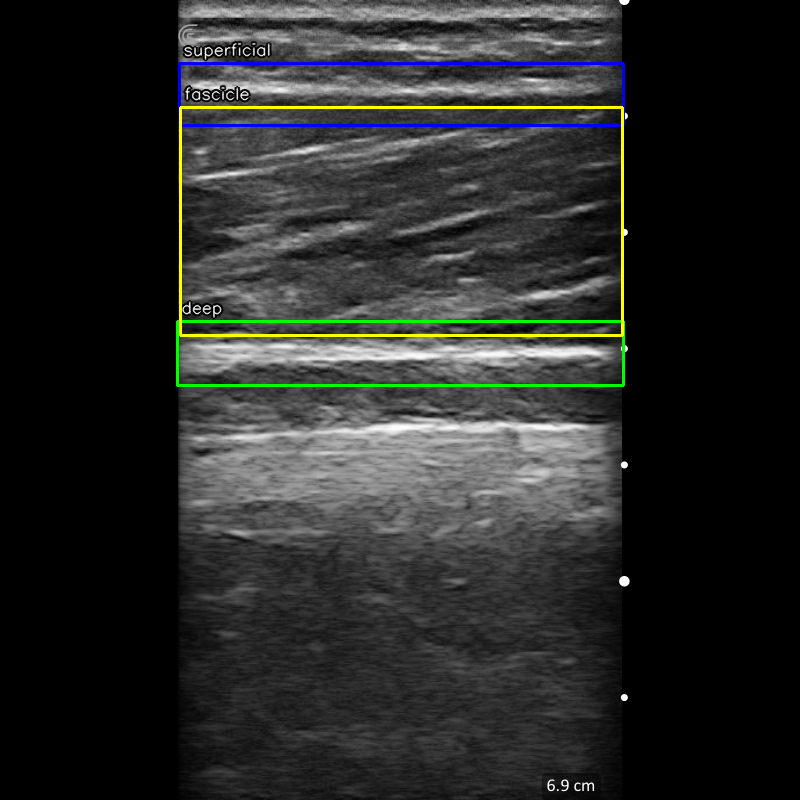

,roi,x,y,width,height
0,superficial,179,63,444,62
1,deep,177,321,446,64
2,fascicle,180,107,442,228


In [3]:
def ensure_bgr(frame: np.ndarray) -> np.ndarray:
    arr = np.asarray(frame)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    if arr.ndim == 2:
        return cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR)
    return arr.copy()


def put_text(frame: np.ndarray, text: str, xy: tuple[int, int], scale: float = 0.65) -> None:
    cv2.putText(frame, text, xy, cv2.FONT_HERSHEY_SIMPLEX, scale, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(frame, text, xy, cv2.FONT_HERSHEY_SIMPLEX, scale, (255, 255, 255), 1, cv2.LINE_AA)


def draw_roi_boxes(frame: np.ndarray, rois_dict: dict, output_path: Path) -> Path:
    vis = ensure_bgr(frame)
    colors = {
        "superficial": (255, 0, 0),
        "deep": (0, 255, 0),
        "fascicle": (0, 255, 255),
    }
    for name, box in rois_dict.items():
        x, y, w, h = map(int, box)
        color = colors.get(name, (255, 255, 255))
        cv2.rectangle(vis, (x, y), (x + w, y + h), color, 2)
        put_text(vis, name, (x + 4, max(22, y - 8)), 0.55)
    cv2.imwrite(str(output_path), vis)
    return output_path

roi_overlay_path = draw_roi_boxes(first_gray, rois, DOC_DIR / "01_input_rois.png")
display(Image(filename=str(roi_overlay_path)))
display(pd.DataFrame([{"roi": key, "x": v[0], "y": v[1], "width": v[2], "height": v[3]} for key, v in rois.items()]))


## 3. Strict pipeline: from detector lines to final FL/PEN/ANG

The strict video uses the saved arrays from the main pipeline. The essential sequence is:

1. `detect_timtrack_geofeature_from_image()` detects aponeurosis lines and candidate fascicle angles from each frame.
2. `extract_fascicle_seed_candidates()`, `cluster_seed_candidates()`, and `select_autonomous_fascicle_seed()` choose a stable early fascicle seed.
3. `run_persistent_affine_video()` provides the KLT/affine prior segment used to stabilize frame-to-frame motion.
4. `run_matlab_aponeurosis_state_video()` filters superficial and deep aponeurosis lines.
5. `run_matlab_2state_kalman()` filters fascicle state and outputs `fascicle_segments`, `FL_px`, `FL_mm`, `PEN_deg`, and `ANG_deg`.
6. `compute_speckle_coherence()`, `compute_motion_consistency()`, `compute_feature_detection_reliability()`, and `compute_geometry_stability()` provide confidence terms for adaptive measurement noise.

Line arrays in the strict runner are MATLAB-style one-based image coordinates. `draw_overlay_frame()` calls `draw_line_1b()`, which subtracts one pixel before drawing.


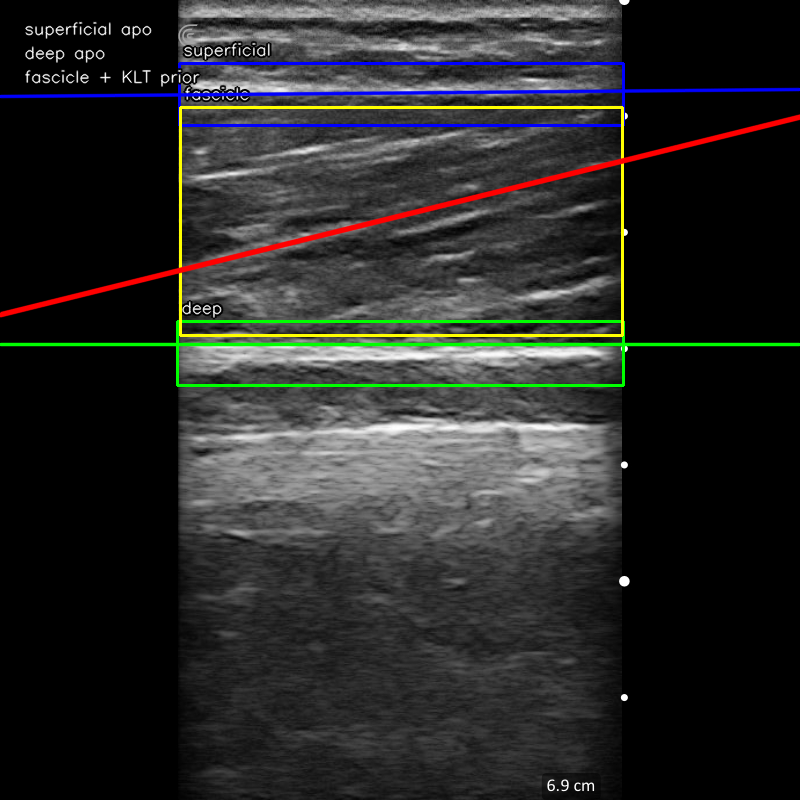

,frame,time_s,ANG_deg,PEN_deg,FL_px,FL_mm,combined_confidence,speckle_zncc
0,0,0.000000,13.800000,13.800000,1073.410940,92.581694,0.972970,NaN
1,1,0.090909,13.738220,13.759200,1077.058470,92.896293,0.972021,0.962183
2,2,0.181818,13.726236,13.739687,1081.929942,93.316457,0.908563,0.879514
3,3,0.272727,13.597392,13.602423,1111.012868,95.824860,0.639216,0.719501
4,4,0.363636,13.658242,13.657419,1108.801101,95.634095,0.607378,0.708276
5,5,0.454545,13.848944,13.848138,1101.108910,94.970643,0.596557,0.688826
6,6,0.545455,13.901586,13.914090,1108.915253,95.643941,0.659603,0.727849
7,7,0.636364,14.090495,14.092261,1110.286529,95.762213,0.853709,0.843227


In [4]:
def line_1b_to_0b(line: np.ndarray) -> np.ndarray:
    return np.asarray(line, dtype=np.float64).reshape(4) - np.asarray([1.0, 1.0, 1.0, 1.0])


def draw_line(frame: np.ndarray, line: np.ndarray, color: tuple[int, int, int], thickness: int = 2, one_based: bool = True) -> None:
    if line is None:
        return
    arr = line_1b_to_0b(line) if one_based else np.asarray(line, dtype=np.float64).reshape(4)
    if not np.all(np.isfinite(arr[:4])):
        return
    p0 = tuple(np.rint(arr[:2]).astype(int))
    p1 = tuple(np.rint(arr[2:4]).astype(int))
    cv2.line(frame, p0, p1, color, thickness, cv2.LINE_AA)


def draw_reference_lines(frame: np.ndarray, arrays_dict: dict, output_path: Path, result_idx: int = 0) -> Path:
    vis = ensure_bgr(frame)
    draw_roi_boxes(frame, rois, output_path)
    vis = cv2.imread(str(output_path))
    draw_line(vis, arrays_dict["sup_apo_lines"][result_idx], (255, 0, 0), 2, one_based=True)
    draw_line(vis, arrays_dict["deep_apo_lines"][result_idx], (0, 255, 0), 2, one_based=True)
    draw_line(vis, arrays_dict["klt_prior_segments"][result_idx], (0, 165, 255), 1, one_based=True)
    draw_line(vis, arrays_dict["fascicle_segments"][result_idx], (0, 0, 255), 3, one_based=True)
    put_text(vis, "superficial apo", (24, 34), 0.55)
    put_text(vis, "deep apo", (24, 58), 0.55)
    put_text(vis, "fascicle + KLT prior", (24, 82), 0.55)
    cv2.imwrite(str(output_path), vis)
    return output_path

reference_lines_path = draw_reference_lines(first_gray, arrays, DOC_DIR / "02_strict_reference_lines_frame0.png")
display(Image(filename=str(reference_lines_path)))

metrics_preview = pd.DataFrame(
    {
        "frame": frame_numbers[:8],
        "time_s": time_s[:8],
        "ANG_deg": arrays["ANG_deg"][:8],
        "PEN_deg": arrays["PEN_deg"][:8],
        "FL_px": arrays["FL_px"][:8],
        "FL_mm": arrays["FL_mm"][:8] if "FL_mm" in arrays else np.nan,
        "combined_confidence": arrays["combined_confidence"][:8],
        "speckle_zncc": arrays["speckle_zncc"][:8],
    }
)
display(metrics_preview)


## 4. The final strict annotated video

The strict annotated MP4 is produced by `save_annotated_video()` in `scripts/run_strict_ultratimtrack_video.py`.

Brief function and variable notes:

| Function or variable | Role in the final annotated video |
|---|---|
| `save_annotated_video(video_path, output_path, rois, arrays, fps, show_kalman_comparison)` | Opens the raw video, loops through `arrays['frame']`, draws each overlay, and writes the MP4. |
| `draw_overlay_frame(frame, rois, arrays, result_idx, show_kalman_comparison)` | Draws ROI boxes, aponeuroses, KLT prior, fascicle lines, FL/PEN/ANG text, and confidence text. |
| `arrays['sup_apo_lines']`, `arrays['deep_apo_lines']` | Filtered aponeurosis lines drawn in blue/green. |
| `arrays['fascicle_segments']` | Selected adaptive Kalman fascicle line. |
| `arrays['fixed_fascicle_segments']` | Normal fixed-R Kalman line, drawn when comparison is enabled. |
| `arrays['FL_mm']`, `arrays['PEN_deg']`, `arrays['ANG_deg']` | Numeric labels written onto each frame. |
| `arrays['combined_confidence']`, `arrays['r_scale']` | Confidence and adaptive-R scale shown as text/color indicator. |


,path,frames,fps,width,height,size_MB
0,/Users/grosbedou/PycharmProjects/NDORMS/result...,84,11.0,800,800,4.400592


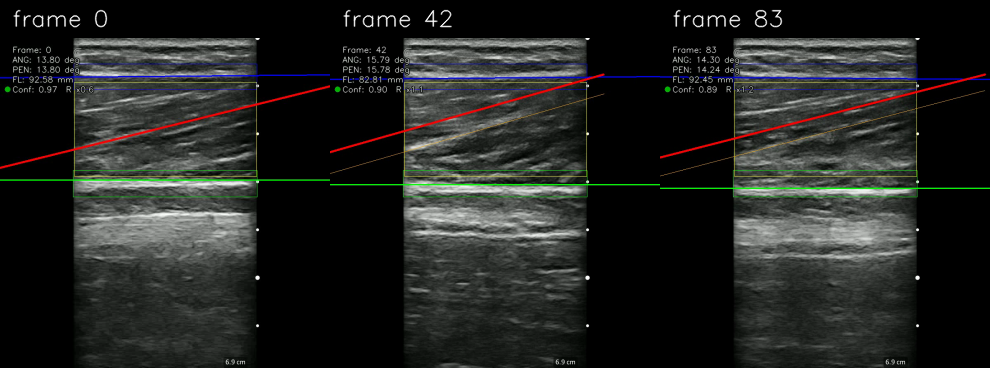

Annotated video path: /Users/grosbedou/PycharmProjects/NDORMS/results/strict_ultratimtrack_runs/june30_4_best/june30_4_best_strict_annotated.mp4


In [5]:
def video_info(path: Path) -> dict:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(path)
    info = {
        "path": str(path),
        "frames": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "fps": float(cap.get(cv2.CAP_PROP_FPS)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        "size_MB": path.stat().st_size / 1024**2,
    }
    cap.release()
    return info


def read_video_frame(path: Path, frame_idx: int) -> np.ndarray:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Could not read frame {frame_idx} from {path}")
    return frame


def make_contact_sheet(video_path: Path, frame_indices: list[int], output_path: Path, *, target_height: int = 330) -> Path:
    panels = []
    for idx in frame_indices:
        frame = read_video_frame(video_path, idx)
        h, w = frame.shape[:2]
        scale = target_height / max(h, 1)
        resized = cv2.resize(frame, (int(round(w * scale)), target_height), interpolation=cv2.INTER_AREA)
        label_bar = np.zeros((38, resized.shape[1], 3), dtype=np.uint8)
        cv2.putText(label_bar, f"frame {idx}", (12, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 1, cv2.LINE_AA)
        panels.append(np.vstack([label_bar, resized]))
    sheet = np.hstack(panels)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), sheet)
    return output_path

annotated_info = video_info(ANNOTATED_VIDEO_PATH)
display(pd.DataFrame([annotated_info]))
annotated_frames = [0, annotated_info["frames"] // 2, annotated_info["frames"] - 1]
annotated_contact_path = make_contact_sheet(
    ANNOTATED_VIDEO_PATH,
    annotated_frames,
    DOC_DIR / "03_strict_annotated_video_contact_sheet.png",
)
display(Image(filename=str(annotated_contact_path)))
print(f"Annotated video path: {ANNOTATED_VIDEO_PATH}")
display(Video(str(ANNOTATED_VIDEO_PATH), embed=False, html_attributes="controls muted"))


## 5. Three-point speckle setup

The three-point overlay is generated from the saved strict result, not from a separate manual measurement. The GUI helper function `generate_three_point_speckle_outputs()` performs the whole speckle stage.

Brief function notes:

| Function | Role |
|---|---|
| `_speckle_config_from_box(block_size)` | Builds `SpeckleConfidenceConfig`; here the box is `41 x 41 px`, search radius is `8 px`, ZNCC low threshold is `0.45`, and forward/backward error threshold is `2 px`. |
| `_candidate_score_rows(frame0, frame1, line, cfg, ...)` | Samples candidate centers along the first fascicle line and scores each by texture variance plus frame 0-to-1 ZNCC. |
| `_select_three_speckle_points(...)` | Chooses the best center point, then places `back`, `center`, and `front` along the fascicle direction. The requested offset is `45 px`; the selected offset is written to the output filename. |
| `_segment_axes(line)` | Computes `t_hat`, the unit vector along the fascicle, and `n_hat`, the perpendicular direction. |

Main setup variables:

| Variable | Meaning |
|---|---|
| `SPECKLE_BOX_SIZE_PX` | Square texture patch size in pixels. |
| `SPECKLE_REQUESTED_OFFSET_PX` | Requested center-to-back and center-to-front spacing. |
| `selected_offset_px` | Actual spacing after validity checks against image borders, ROI, and aponeuroses. |
| `initial_points` | The initial `back`, `center`, and `front` speckle point coordinates. |
| `candidate_scores` | Candidate point table used to pick the starting center point. |


In [6]:
def _sheet_cells_to_rows(xml_bytes: bytes) -> list[list[object]]:
    ns = {"m": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}
    root = ET.fromstring(xml_bytes)
    rows = []
    for row in root.findall(".//m:sheetData/m:row", ns):
        values = []
        for cell in row.findall("m:c", ns):
            cell_type = cell.attrib.get("t")
            if cell_type == "inlineStr":
                text = cell.findtext("m:is/m:t", default="", namespaces=ns)
                values.append(text)
            elif cell_type == "b":
                text = cell.findtext("m:v", default="", namespaces=ns)
                values.append(text == "1")
            else:
                text = cell.findtext("m:v", default="", namespaces=ns)
                if text == "":
                    values.append(np.nan)
                else:
                    try:
                        number = float(text)
                        values.append(int(number) if number.is_integer() else number)
                    except ValueError:
                        values.append(text)
        rows.append(values)
    return rows


def read_simple_xlsx_sheet(path: Path, sheet_index: int) -> pd.DataFrame:
    sheet_name = f"xl/worksheets/sheet{sheet_index}.xml"
    with zipfile.ZipFile(path) as zf:
        rows = _sheet_cells_to_rows(zf.read(sheet_name))
    if not rows:
        return pd.DataFrame()
    header = [str(value) for value in rows[0]]
    return pd.DataFrame(rows[1:], columns=header)

speckle_tracking_df = read_simple_xlsx_sheet(SPECKLE_XLSX_PATH, 1)
speckle_summary_df = read_simple_xlsx_sheet(SPECKLE_XLSX_PATH, 2)
speckle_setup_df = read_simple_xlsx_sheet(SPECKLE_XLSX_PATH, 3)
speckle_candidate_df = read_simple_xlsx_sheet(SPECKLE_XLSX_PATH, 4)

for column in ["frame", "time_s", "x", "y", "d_parallel_px", "d_perpendicular_px", "zncc", "forward_backward_error", "strain_back_front_percent"]:
    if column in speckle_tracking_df.columns:
        speckle_tracking_df[column] = pd.to_numeric(speckle_tracking_df[column], errors="coerce")
for column in ["x0", "y0", "selected_offset_px", "requested_offset_px", "t_x", "t_y", "n_x", "n_y"]:
    if column in speckle_setup_df.columns:
        speckle_setup_df[column] = pd.to_numeric(speckle_setup_df[column], errors="coerce")
for column in ["fraction", "x", "y", "texture_variance", "zncc_0_1", "combined_score"]:
    if column in speckle_candidate_df.columns:
        speckle_candidate_df[column] = pd.to_numeric(speckle_candidate_df[column], errors="coerce")

display(Markdown("### Speckle summary"))
display(speckle_summary_df)
display(Markdown("### Initial point setup"))
display(speckle_setup_df)
display(Markdown("### Top candidate centers"))
display(speckle_candidate_df.head(10))


### Speckle summary

,box_size_px,requested_offset_px,selected_offset_px,mm_per_pixel,units_for_overlay,mean_zncc,invalid_rows,fallback_rows,max_abs_parallel_displacement_px,peak_abs_back_front_strain_percent
0,41,45,45,0.08625,mm,0.904708,29,29,60.2945,28.027159


### Initial point setup

,point_id,x0,y0,box_size_px,requested_offset_px,selected_offset_px,t_x,t_y,n_x,n_y
0,back,391.579734,219.546006,41,45,45,-0.971134,0.238533,-0.238533,-0.971134
1,center,347.878691,230.280011,41,45,45,-0.971134,0.238533,-0.238533,-0.971134
2,front,304.177648,241.014017,41,45,45,-0.971134,0.238533,-0.238533,-0.971134


### Top candidate centers

,fraction,x,y,texture_variance,zncc_0_1,match_ok,texture_score,zncc_score,combined_score
0,0.550,347.878691,230.280011,1443.945557,0.988133,True,1.000000,1,1.000000
1,0.555,342.666560,231.560233,1517.052856,0.988499,True,1.000000,1,1.000000
2,0.560,337.454429,232.840455,1481.292725,0.987788,True,1.000000,1,1.000000
3,0.565,332.242299,234.120677,1406.875977,0.986405,True,1.000000,1,1.000000
4,0.585,311.393775,239.241566,1425.396240,0.985344,True,1.000000,1,1.000000
5,0.590,306.181645,240.521788,1413.989624,0.984659,True,1.000000,1,1.000000
6,0.595,300.969514,241.802010,1449.693604,0.984797,True,1.000000,1,1.000000
7,0.600,295.757383,243.082232,1410.956421,0.984657,True,1.000000,1,1.000000
8,0.580,316.605906,237.961344,1382.701660,0.984729,True,0.991804,1,0.996312
9,0.545,353.090822,228.999789,1333.260620,0.987796,True,0.949901,1,0.977455


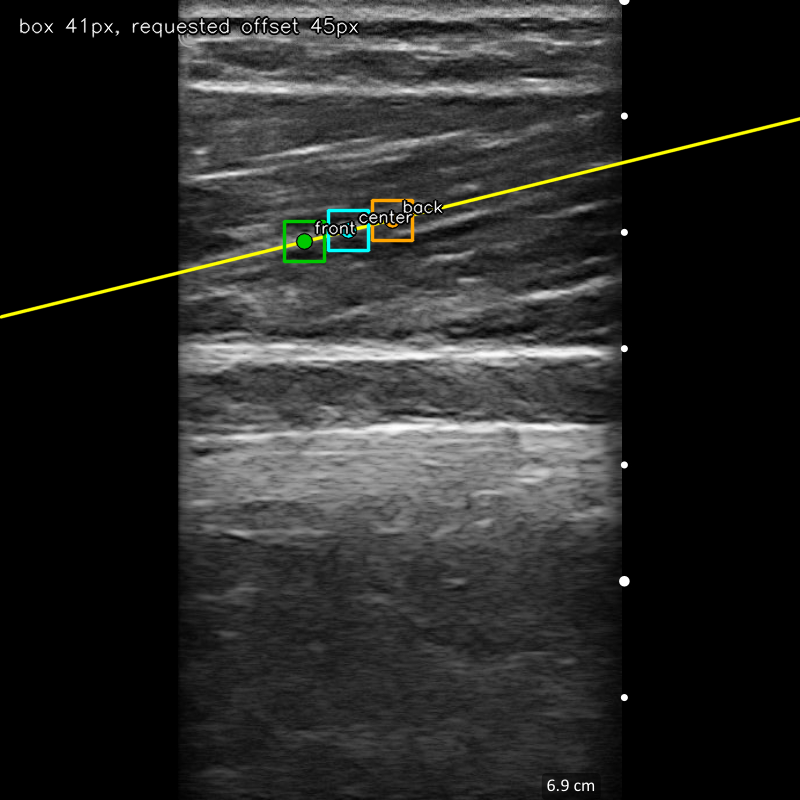

In [7]:
def draw_speckle_setup_image(frame: np.ndarray, output_path: Path) -> Path:
    vis = ensure_bgr(frame)
    # The GUI speckle overlay uses fascicle_end_segments from the NPZ directly.
    line = np.asarray(arrays["fascicle_end_segments"][0], dtype=np.float64).reshape(4)
    cv2.line(vis, tuple(np.rint(line[:2]).astype(int)), tuple(np.rint(line[2:]).astype(int)), (0, 255, 255), 2, cv2.LINE_AA)
    for _, row in speckle_setup_df.iterrows():
        point_id = str(row["point_id"])
        x = float(row["x0"])
        y = float(row["y0"])
        half = SPECKLE_BOX_SIZE_PX // 2
        color = {"back": (0, 165, 255), "center": (255, 255, 0), "front": (0, 200, 0)}.get(point_id, (255, 255, 255))
        cv2.rectangle(vis, (int(round(x)) - half, int(round(y)) - half), (int(round(x)) + half, int(round(y)) + half), color, 2, cv2.LINE_AA)
        cv2.circle(vis, (int(round(x)), int(round(y))), 7, color, -1, cv2.LINE_AA)
        cv2.circle(vis, (int(round(x)), int(round(y))), 8, (0, 0, 0), 1, cv2.LINE_AA)
        put_text(vis, point_id, (int(round(x)) + 10, int(round(y)) - 8), 0.55)
    put_text(vis, f"box {SPECKLE_BOX_SIZE_PX}px, requested offset {SPECKLE_REQUESTED_OFFSET_PX:.0f}px", (18, 32), 0.65)
    cv2.imwrite(str(output_path), vis)
    return output_path

speckle_setup_image_path = draw_speckle_setup_image(first_gray, DOC_DIR / "04_speckle_initial_points.png")
display(Image(filename=str(speckle_setup_image_path)))


## 6. Three-point speckle tracking and QC variables

After the initial points are chosen, `_track_speckle_points_independent()` tracks each point independently from frame to frame.

Brief variable notes:

| Variable | Meaning |
|---|---|
| `positions` | Array shaped `(n_frames, 3, 2)`. It stores current x/y coordinates for `back`, `center`, and `front`. |
| `dxdy` | Frame-to-frame displacement for each point. |
| `zncc` | Zero-normalized cross-correlation score between the template patch and matched patch. Higher is better. |
| `forward_backward_error` | Difference after matching forward and then backward. Lower is better. |
| `valid` | True when ZNCC and forward/backward checks pass. |
| `fallback_used` | True when the point used the median displacement fallback instead of accepting its own local match. |
| `d_parallel_px` | Cumulative displacement projected along the fascicle direction `t_hat`. |
| `d_perpendicular_px` | Cumulative displacement projected perpendicular to the fascicle. |
| `strain_back_front_percent` | Percent change in back-to-front spacing along `t_hat`. Negative means shortening; positive means lengthening. |


,frame,time_s,point_id,box_size_px,offset_px,x,y,dx,dy,cumulative_dx,...,strain_back_center_percent,strain_center_front_percent,x_mm,y_mm,dx_mm,dy_mm,cumulative_dx_mm,cumulative_dy_mm,d_parallel_mm,d_perpendicular_mm
0,0,0.000000,back,41,45,391.579734,219.546006,0.000000,0.000000,0.000000,...,0.000000,0.000000,33.773752,18.935843,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,0.000000,center,41,45,347.878691,230.280011,0.000000,0.000000,0.000000,...,0.000000,0.000000,30.004537,19.861651,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0,0.000000,front,41,45,304.177648,241.014017,0.000000,0.000000,0.000000,...,0.000000,0.000000,26.235322,20.787459,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1,0.090909,back,41,45,392.000000,220.000000,0.420266,0.453994,0.420266,...,2.414171,0.786170,33.810000,18.975000,0.036248,0.039157,0.036248,0.039157,-0.025861,-0.046673
4,1,0.090909,center,41,45,347.000000,230.000000,-0.878691,-0.280011,-0.878691,...,2.414171,0.786170,29.928750,19.837500,-0.075787,-0.024151,-0.075787,-0.024151,0.067839,0.041532
5,1,0.090909,front,41,45,303.000000,241.000000,-1.177648,-0.014017,-1.177648,...,2.414171,0.786170,26.133750,20.786250,-0.101572,-0.001209,-0.101572,-0.001209,0.098352,0.025402
6,2,0.181818,back,41,45,393.000000,221.000000,1.000000,1.000000,1.420266,...,-0.273979,0.786170,33.896250,19.061250,0.086250,0.086250,0.122498,0.125407,-0.089048,-0.151007
7,2,0.181818,center,41,45,349.000000,230.000000,2.000000,0.000000,1.121309,...,-0.273979,0.786170,30.101250,19.837500,0.172500,0.000000,0.096713,-0.024151,-0.099682,0.000385
8,2,0.181818,front,41,45,305.000000,241.000000,2.000000,0.000000,0.822352,...,-0.273979,0.786170,26.306250,20.786250,0.172500,0.000000,0.070928,-0.001209,-0.069169,-0.015745
9,3,0.272727,back,41,45,400.000000,225.000000,7.000000,4.000000,8.420266,...,2.698098,3.758247,34.500000,19.406250,0.603750,0.345000,0.726248,0.470407,-0.593076,-0.630063


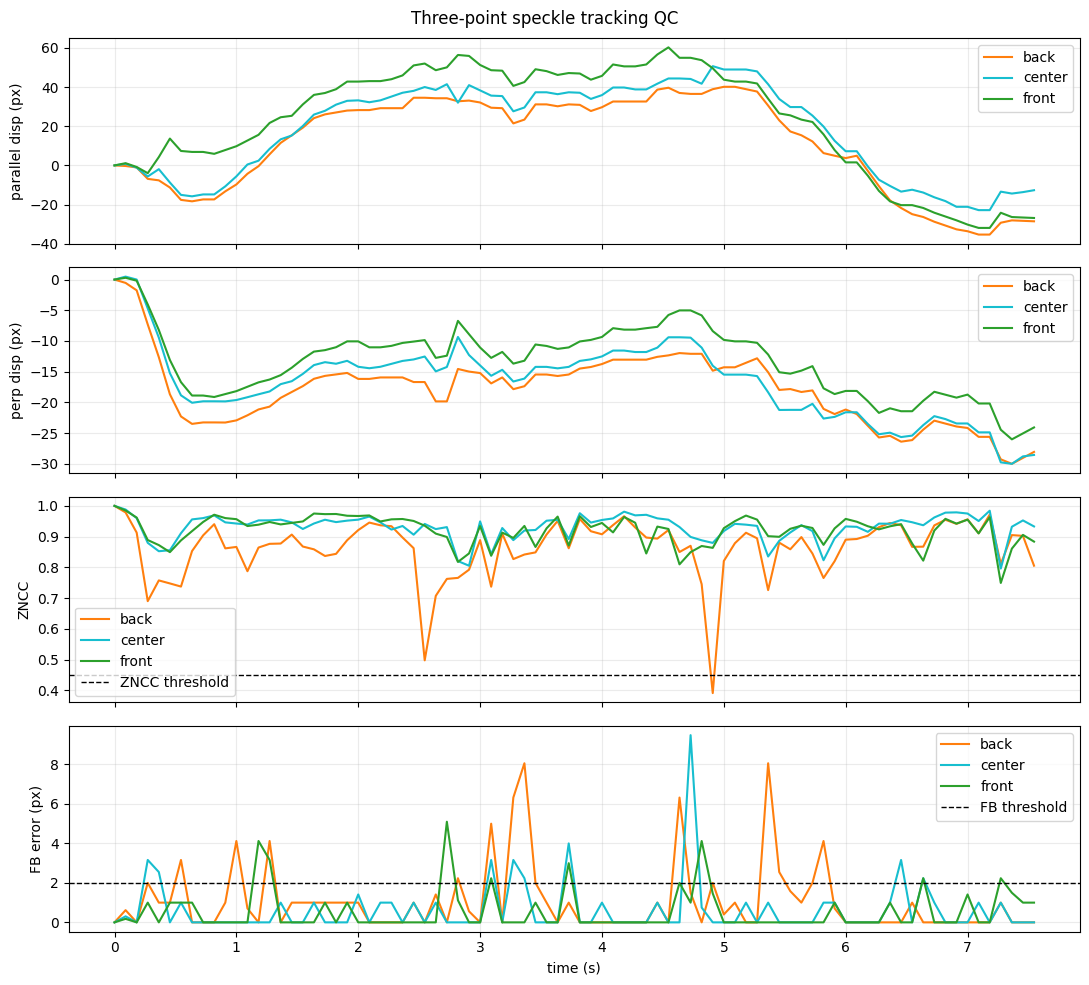

Saved QC plot: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/step_by_step_documentation/05_speckle_tracking_qc.png


In [8]:
display(speckle_tracking_df.head(12))

point_colors = {"back": "tab:orange", "center": "tab:cyan", "front": "tab:green"}
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for point_id, color in point_colors.items():
    sub = speckle_tracking_df[speckle_tracking_df["point_id"] == point_id]
    axes[0].plot(sub["time_s"], sub["d_parallel_px"], label=point_id, color=color)
    axes[1].plot(sub["time_s"], sub["d_perpendicular_px"], label=point_id, color=color)
    axes[2].plot(sub["time_s"], sub["zncc"], label=point_id, color=color)
    axes[3].plot(sub["time_s"], sub["forward_backward_error"], label=point_id, color=color)
axes[2].axhline(0.45, color="black", linestyle="--", linewidth=1, label="ZNCC threshold")
axes[3].axhline(2.0, color="black", linestyle="--", linewidth=1, label="FB threshold")
axes[0].set_ylabel("parallel disp (px)")
axes[1].set_ylabel("perp disp (px)")
axes[2].set_ylabel("ZNCC")
axes[3].set_ylabel("FB error (px)")
axes[3].set_xlabel("time (s)")
for ax in axes:
    ax.legend(loc="best")
    ax.grid(alpha=0.25)
fig.suptitle("Three-point speckle tracking QC")
fig.tight_layout()
speckle_qc_path = DOC_DIR / "05_speckle_tracking_qc.png"
fig.savefig(speckle_qc_path, dpi=180)
plt.show()
print(f"Saved QC plot: {speckle_qc_path}")


## 7. The three-point speckle overlay video

The speckle overlay MP4 is produced by `_write_speckle_overlay_video()` through `generate_three_point_speckle_outputs()`.

What is drawn on each frame:

| Overlay item | Source variable |
|---|---|
| Yellow fascicle line | `fascicle_segments[frame_idx]` loaded from the strict NPZ. |
| Colored point trails | `tracking['positions']` for `back`, `center`, `front`. |
| Patch boxes | Current point position plus `box_size_px`. |
| Red ring on fallback frames | `tracking['fallback_used']` and `tracking['valid']`. |
| Header text | `box_size_px`, `requested_offset_px`, `selected_offset_px`, and `strain_back_front_percent`. |
| Right-side graphs | `_speckle_series_for_overlay()` computes parallel, y, and x displacement series. |


,path,frames,fps,width,height,size_MB
0,/Users/grosbedou/PycharmProjects/NDORMS/result...,84,11.0,1340,800,4.340283


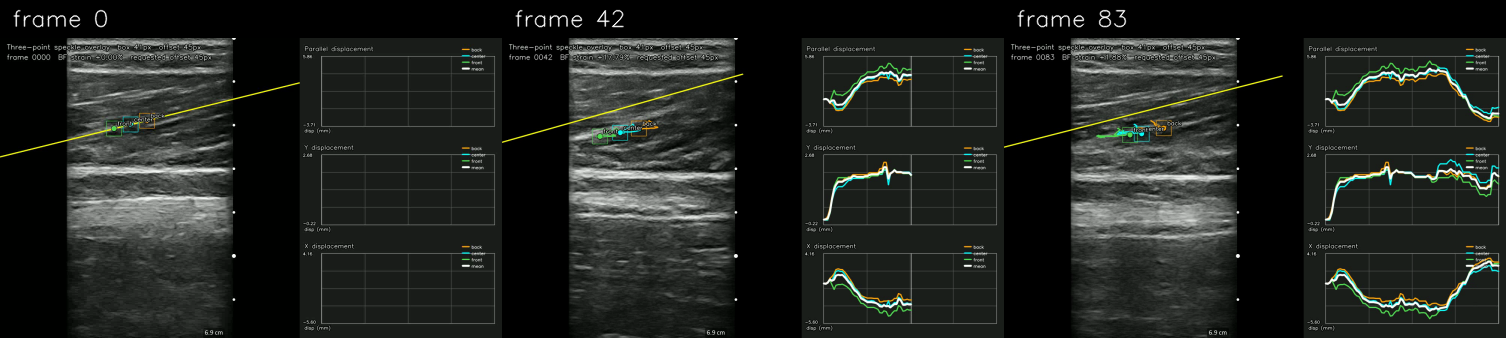

Three-point speckle overlay path: /Users/grosbedou/PycharmProjects/NDORMS/results/strict_ultratimtrack_runs/june30_4_best/june30_4_best_three_point_speckle_overlay_box41px_offset45px.mp4


In [9]:
speckle_info = video_info(SPECKLE_OVERLAY_PATH)
display(pd.DataFrame([speckle_info]))
speckle_frames = [0, speckle_info["frames"] // 2, speckle_info["frames"] - 1]
speckle_contact_path = make_contact_sheet(
    SPECKLE_OVERLAY_PATH,
    speckle_frames,
    DOC_DIR / "06_three_point_speckle_overlay_contact_sheet.png",
    target_height=300,
)
display(Image(filename=str(speckle_contact_path)))
print(f"Three-point speckle overlay path: {SPECKLE_OVERLAY_PATH}")
display(Video(str(SPECKLE_OVERLAY_PATH), embed=False, html_attributes="controls muted"))


## 8. Optional regeneration cell

The cells above document the already-generated outputs. If you intentionally want to regenerate the videos, set one of these flags to `True` and run the cell.

Regeneration writes to the same output paths, so keep the flags as `False` for normal documentation use.


In [10]:
REGENERATE_STRICT_ANNOTATED_VIDEO = False
REGENERATE_THREE_POINT_SPECKLE_OVERLAY = False

if REGENERATE_STRICT_ANNOTATED_VIDEO:
    from scripts.run_strict_ultratimtrack_video import save_annotated_video

    save_annotated_video(
        VIDEO_PATH,
        ANNOTATED_VIDEO_PATH,
        rois,
        arrays,
        fps,
        show_kalman_comparison=bool(metadata.get("compare_to_fixed_kalman")),
    )
else:
    print("Strict annotated video regeneration skipped.")

if REGENERATE_THREE_POINT_SPECKLE_OVERLAY:
    from scripts.strict_ultratimtrack_gui import generate_three_point_speckle_outputs

    result = generate_three_point_speckle_outputs(
        video_path=VIDEO_PATH,
        npz_path=STRICT_NPZ_PATH,
        run_dir=RUN_DIR,
        name=DATASET_NAME,
        roi_path=ROI_PATH,
        box_size_px=SPECKLE_BOX_SIZE_PX,
        requested_offset_px=SPECKLE_REQUESTED_OFFSET_PX,
    )
    display(pd.DataFrame([result]))
else:
    print("Three-point speckle overlay regeneration skipped.")


Strict annotated video regeneration skipped.
Three-point speckle overlay regeneration skipped.


## 9. Output checklist

The important outputs for `june30_4_best` are below. The two MP4s are the final strict annotated video and the three-point speckle overlay requested here.


In [11]:
final_outputs = [
    ANNOTATED_VIDEO_PATH,
    SPECKLE_OVERLAY_PATH,
    SPECKLE_XLSX_PATH,
    DOC_DIR / "01_input_rois.png",
    DOC_DIR / "02_strict_reference_lines_frame0.png",
    DOC_DIR / "03_strict_annotated_video_contact_sheet.png",
    DOC_DIR / "04_speckle_initial_points.png",
    DOC_DIR / "05_speckle_tracking_qc.png",
    DOC_DIR / "06_three_point_speckle_overlay_contact_sheet.png",
]
checklist = pd.DataFrame(
    [
        {
            "exists": path.exists(),
            "size_MB": path.stat().st_size / 1024**2 if path.exists() else np.nan,
            "path": str(path),
        }
        for path in final_outputs
    ]
)
display(checklist)


,exists,size_MB,path
0,True,4.400592,/Users/grosbedou/PycharmProjects/NDORMS/result...
1,True,4.340283,/Users/grosbedou/PycharmProjects/NDORMS/result...
2,True,0.048154,/Users/grosbedou/PycharmProjects/NDORMS/result...
3,True,0.423521,/Users/grosbedou/PycharmProjects/NDORMS/result...
4,True,0.434969,/Users/grosbedou/PycharmProjects/NDORMS/result...
5,True,0.345581,/Users/grosbedou/PycharmProjects/NDORMS/result...
6,True,0.446117,/Users/grosbedou/PycharmProjects/NDORMS/result...
7,True,0.386338,/Users/grosbedou/PycharmProjects/NDORMS/result...
8,True,0.407349,/Users/grosbedou/PycharmProjects/NDORMS/result...
